In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# generate 2D correlated gaussian 
def generate_2d_gaussian(N, mean, cov_matrix):
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    transform_matrix = eigenvectors @ np.diag(np.sqrt(eigenvalues))
    z = np.random.randn(N, 2)  # Standard normal samples
    data = z @ transform_matrix.T + mean  # Transforming to required distribution
    
    return data[:, 0], data[:, 1]

In [3]:
#  Gaussian PDF
def gaussian_pdf(x, y, mean, cov_matrix):
    det_cov = cov_matrix[0,0] * cov_matrix[1,1] - cov_matrix[0,1]**2
    inv_cov = np.linalg.inv(cov_matrix)
    
    X = np.stack((x - mean[0], y - mean[1]), axis=0)
    exponent = -0.5 * np.sum(X * (inv_cov @ X), axis=0)
    
    normalization = 1 / (2 * np.pi * np.sqrt(det_cov))
    return normalization * np.exp(exponent)

In [7]:
def gaussian_pdf(x, y, mean, cov_matrix):
    det_cov = cov_matrix[0,0] * cov_matrix[1,1] - cov_matrix[0,1]**2
    inv_cov = np.linalg.inv(cov_matrix)

    # Reshape X and Y into 2D 
    x_flat = x.flatten()
    y_flat = y.flatten()
    X = np.stack((x_flat - mean[0], y_flat - mean[1]), axis=1)  # Shape (10000, 2)

    exponent = -0.5 * np.sum(X @ inv_cov * X, axis=1)  # Shape (10000,)

    normalization = 1 / (2 * np.pi * np.sqrt(det_cov))
    Z = normalization * np.exp(exponent)

    return Z.reshape(x.shape)  # Reshape back 


In [5]:
mean = np.array([0, 0])

#covariance matrices
cov_matrices = {
    "Negative Correlation": np.array([[1, -0.8], [-0.8, 1]]),
    "Independent Variables": np.array([[1, 0], [0, 1]]),
    "Positive Correlation": np.array([[1, 0.8], [0.8, 1]])
}


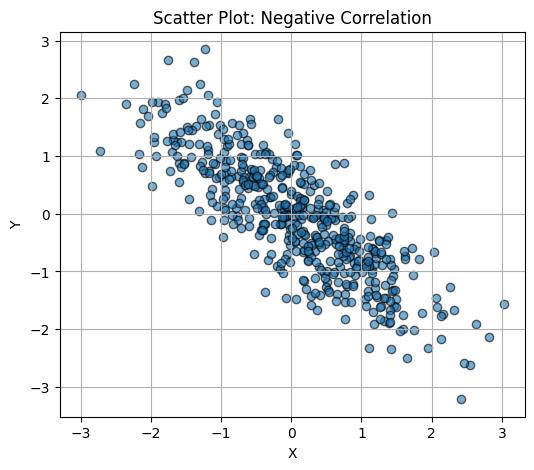

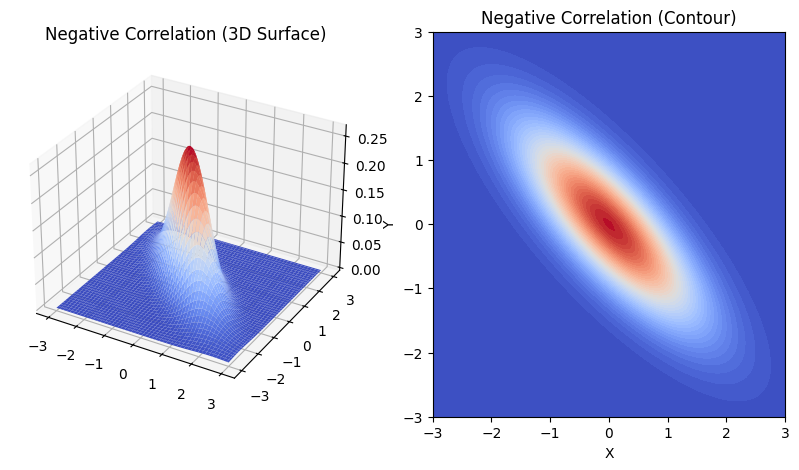

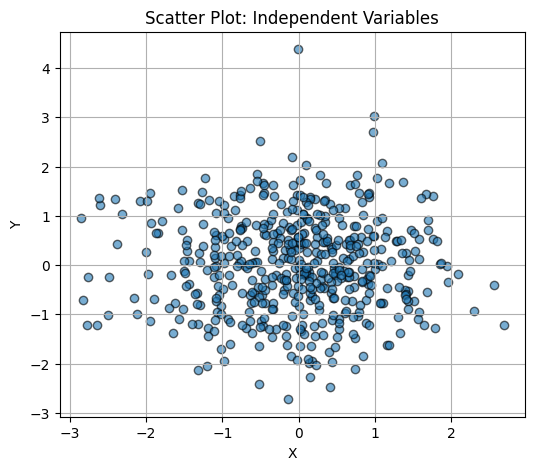

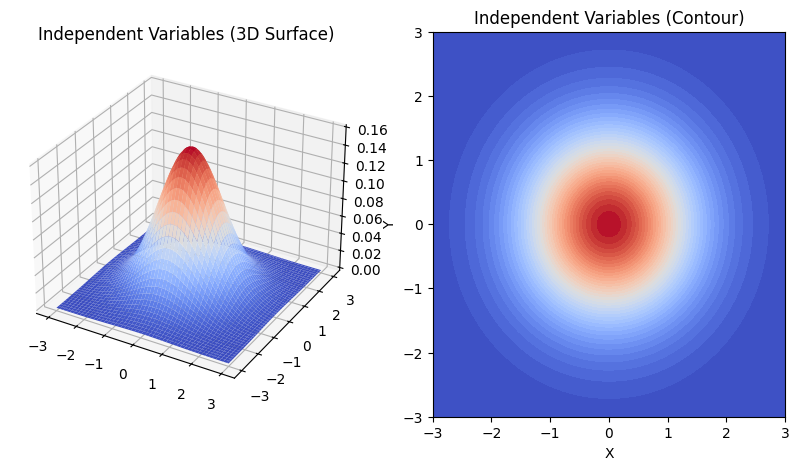

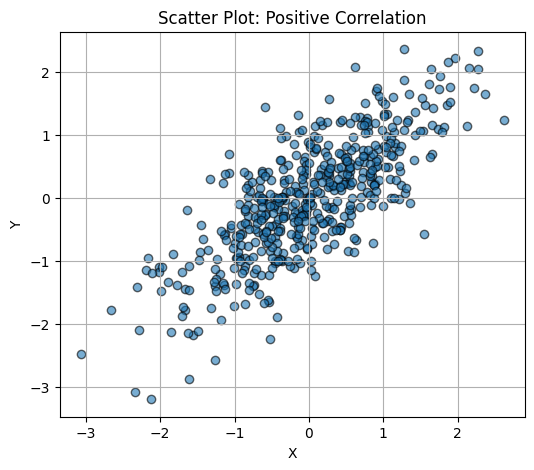

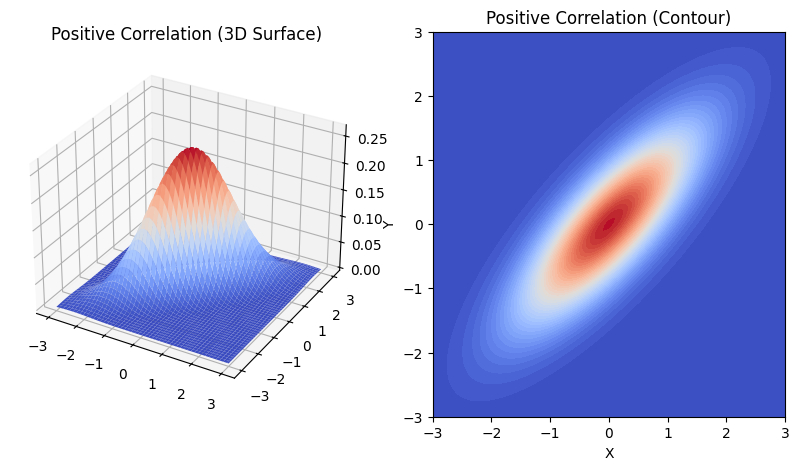

In [8]:
# Generate and plot data for each case
N = 500
for label, cov in cov_matrices.items():
    x, y = generate_2d_gaussian(N, mean, cov)
    
    # Scatter Plot
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.6, edgecolors='k')
    plt.title(f"Scatter Plot: {label}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()
    
    # Gaussian PDF Plot
    plot_gaussian_pdf(mean, cov, label)

In [10]:
# Question 2

import numpy as np
import matplotlib.pyplot as plt

In [11]:
# generate 2D Gaussian 
def generate_2d_gaussian(N, mean, cov_matrix):
    # Cholesky 
    L = np.linalg.cholesky(cov_matrix)

    Z = np.random.randn(N, 2)  # Shape (N, 2)

    X = Z @ L.T + mean  # Shape (N, 2)
    return X

In [12]:
mean = np.array([0, 0])

cov_matrices = {
    "σ1²=1, σ2²=1, σ12=0": np.array([[1, 0], [0, 1]]),
    "σ1²=0.2, σ2²=0.2, σ12=0": np.array([[0.2, 0], [0, 0.2]]),
    "σ1²=2, σ2²=2, σ12=0": np.array([[2, 0], [0, 2]]),
    "σ1²=0.2, σ2²=2, σ12=0": np.array([[0.2, 0], [0, 2]]),
    "σ1²=2, σ2²=0.2, σ12=0": np.array([[2, 0], [0, 0.2]]),
    "σ1²=1, σ2²=1, σ12=0.5": np.array([[1, 0.5], [0.5, 1]]),
    "σ1²=0.3, σ2²=2, σ12=0.5": np.array([[0.3, 0.5], [0.5, 2]]),
    "σ1²=0.3, σ2²=2, σ12=-0.5": np.array([[0.3, -0.5], [-0.5, 2]])
}

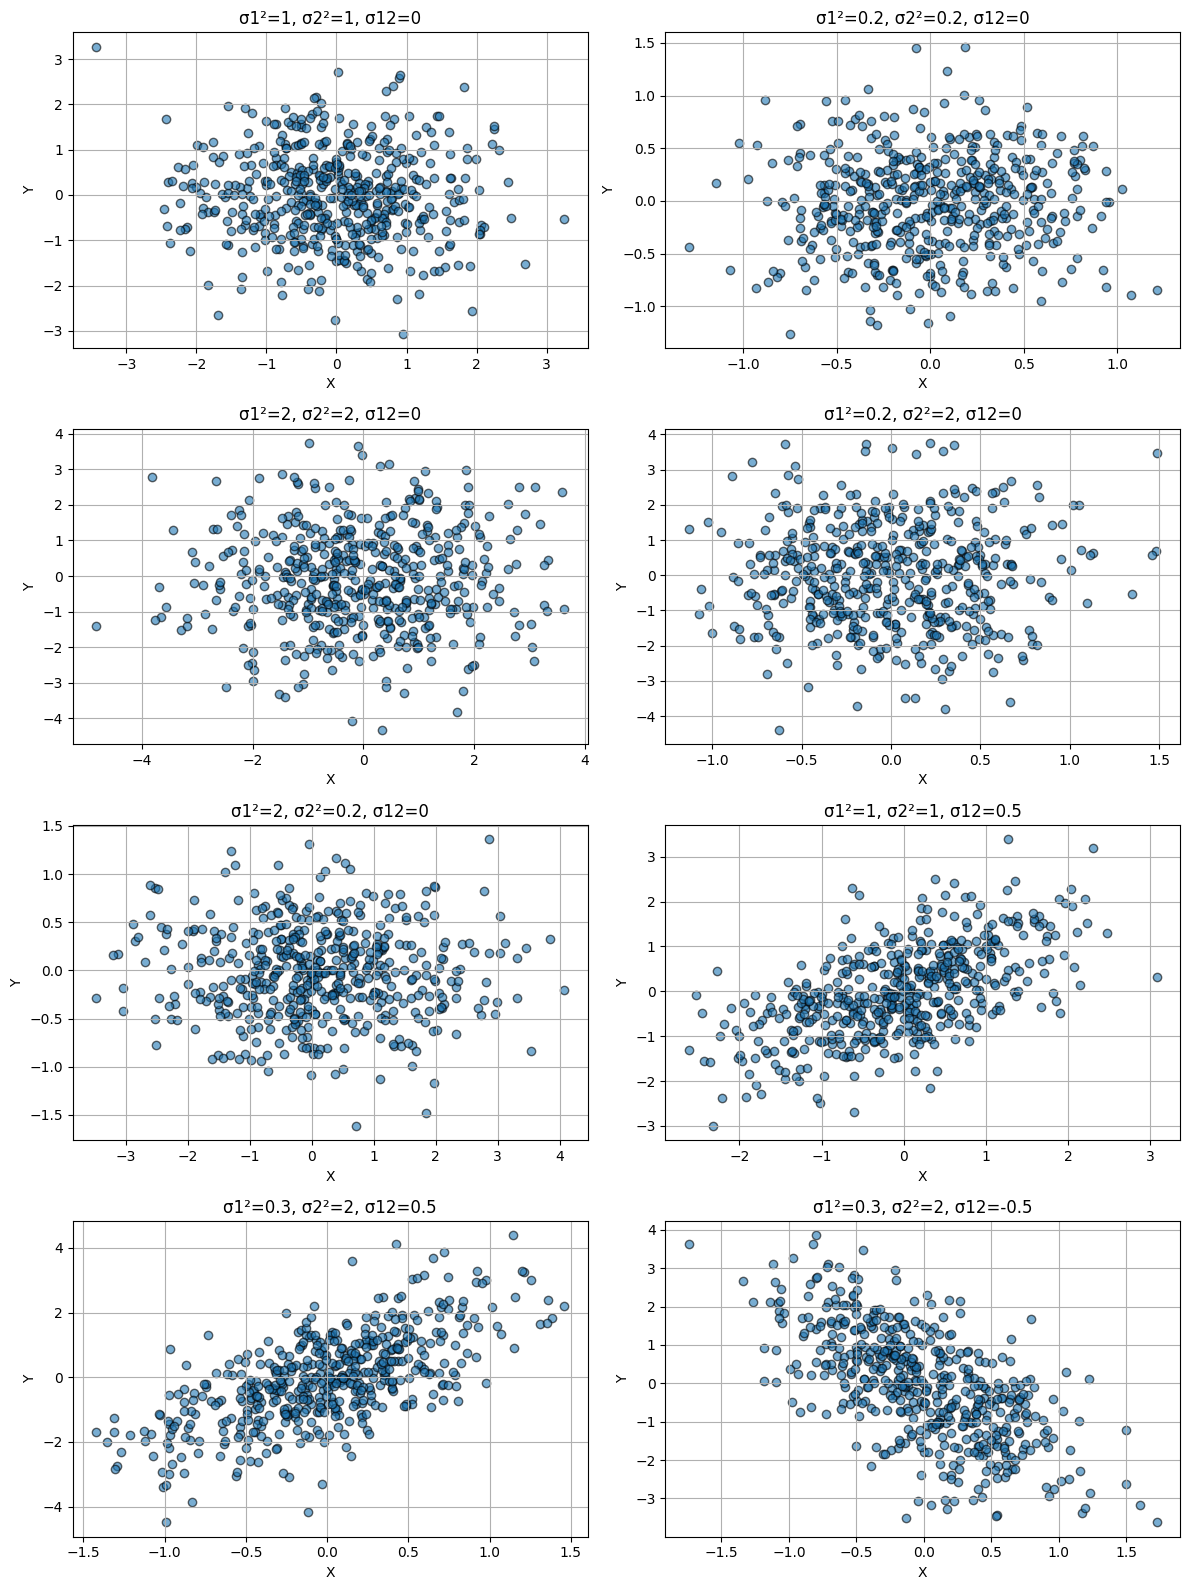

In [14]:
N = 500

# Generate and plot data
fig, axes = plt.subplots(4, 2, figsize=(12, 16))  
axes = axes.flatten()

for i, (label, cov) in enumerate(cov_matrices.items()):
    data = generate_2d_gaussian(N, mean, cov)

    # Scatter plot
    axes[i].scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='k')
    axes[i].set_title(label)
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Y")
    axes[i].grid(True)

plt.tight_layout()
plt.show()